In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
import seaborn as sns

Ce bloc importe les bibliothèques nécessaires pour la manipulation des données (Pandas, NumPy), l’entraînement du modèle (scikit-learn), et la visualisation (Matplotlib, Seaborn).

In [ ]:
# Pour la reproductibilité
np.random.seed(42)

# Génération de 500 repas
n = 500

# Caractéristiques nutritionnelles simulées
glucides = np.random.randint(20, 100, n)
proteines = np.random.randint(5, 40, n)
lipides = np.random.randint(3, 30, n)
fibres = np.random.randint(1, 10, n)
index_glycemique = np.random.randint(35, 95, n)
calories = glucides * 4 + proteines * 4 + lipides * 9  # estimation simplifiée

# Glycémie simulée (formule simplifiée)
glycemie = (
    0.6 * glucides +
    0.2 * index_glycemique -
    0.5 * fibres +
    np.random.normal(0, 10, n)  # ajout de bruit (variabilité naturelle)
).astype(int)

# Assemblage dans un DataFrame
df = pd.DataFrame({
    'glucides': glucides,
    'proteines': proteines,
    'lipides': lipides,
    'fibres': fibres,
    'index_glycemique': index_glycemique,
    'calories': calories,
    'glycemie': glycemie
})

# Affichage des 5 premières lignes
print(df.head())

# Enregistrement dans un fichier CSV si tu veux l’utiliser plus tard
df.to_csv("dataset_glycemie.csv", index=False)


   glucides  proteines  lipides  fibres  index_glycemique  calories  glycemie
0        71         20       27       7                36       607        40
1        34         18       25       2                57       433        35
2        91         35        5       1                78       549        67
3        80          9       26       9                36       590        50
4        40         39       25       1                72       541        46


Ce bloc affiche les premières lignes du jeu de données afin d’avoir un aperçu de sa structure et de son contenu.

In [ ]:
X = df.drop('glycemie', axis=1)  # Variables explicatives
y = df['glycemie']               # Variable cible

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0)



Ce bloc divise les données en deux ensembles : un pour l’entraînement du modèle et un autre pour le test. Cela permet d’évaluer les performances du modèle sur des données jamais vues.

In [ ]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mae'])

In [ ]:
history = model.fit(X_train, y_train, epochs=500, batch_size=4, validation_split=0.2, verbose=1)

Epoch 1/500
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 40.8049 - mae: 40.8049 - val_loss: 11.2526 - val_mae: 11.2526
Epoch 2/500
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10.4962 - mae: 10.4962 - val_loss: 9.7867 - val_mae: 9.7867
Epoch 3/500
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.0555 - mae: 9.0555 - val_loss: 9.7570 - val_mae: 9.7570
Epoch 4/500
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.2652 - mae: 9.2652 - val_loss: 9.2610 - val_mae: 9.2610
Epoch 5/500
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.0818 - mae: 9.0818 - val_loss: 10.0366 - val_mae: 10.0366
Epoch 6/500
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10.0854 - mae: 10.0854 - val_loss: 9.4343 - val_mae: 9.4343
Epoch 7/500
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.3768 - mae: 10.3768 - val_loss: 9.2624 - val_mae: 9.2624
Epoch 8/500
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.2130 - mae: 9.2130 - val_loss: 9.0867 - val_mae: 9.0867
Epoch 9/500
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 

Ce bloc entraîne un modèle de régression linéaire. Le modèle apprend à prédire le taux de diabète à partir des habitudes alimentaires.

In [ ]:
y_pred = model.predict(X_test).flatten()
comparison = pd.DataFrame({
    'Glycémie réelle (mg/dL)': y_test.values,
    'Glycémie prédite (mg/dL)': y_pred,
    'Erreur (mg/dL)': np.abs(y_test.values - y_pred)
})
print(comparison.head(5))

Ce bloc utilise le modèle entraîné pour prédire le taux de diabète sur les données de test. On peut ensuite comparer ces prédictions aux vraies valeurs.

In [ ]:
loss, mae = model.evaluate(X_test, y_test)
print(f"Mean Absolute Error sur le test: {mae:.2f} mg/dL")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 12.1526 - mae: 12.1526
Mean Absolute Error sur le test: 12.01 mg/dL


In [ ]:
new_meal = np.array([[45, 18, 7, 5, 60, 330]])
new_meal_scaled = scaler.transform(new_meal)
predicted_glycemia = model.predict(new_meal_scaled)
print(f"Taux de glycémie prédit : {predicted_glycemia[0][0]:.2f} mg/dL")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
Taux de glycémie prédit : 28.69 mg/dL


Ce bloc utilise le modèle entraîné pour prédire le taux de diabète sur les données de test. On peut ensuite comparer ces prédictions aux vraies valeurs.

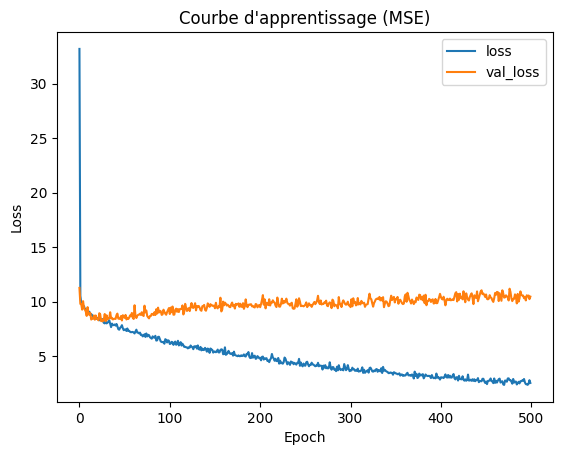

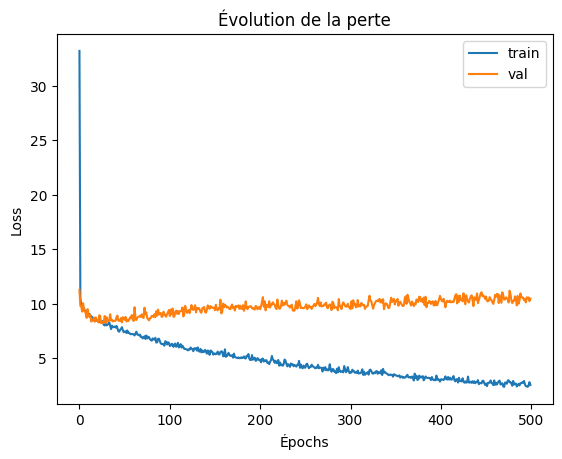

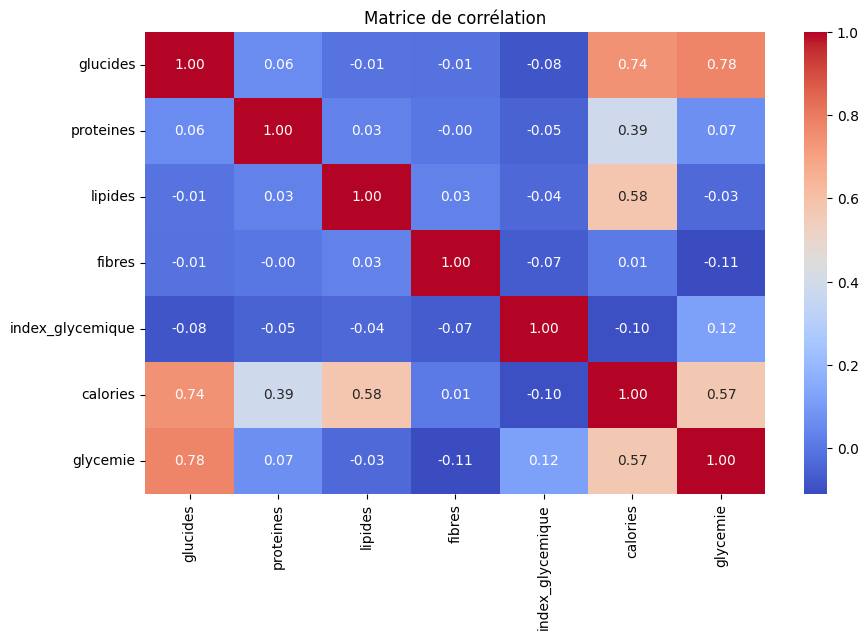

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Taux de glycémie prédit : 32.47 mg/dL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Repas 1 → Glycémie prédite : 43.42 mg/dL
Repas 2 → Glycémie prédite : 30.61 mg/dL
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Comparaison sur 5 exemples :
   Glycémie réelle (mg/dL)  Glycémie prédite (mg/dL)
0                       63                 62.423893
1                       60                 37.487270
2                       68                 70.405029
3                       46                 58.602848
4                       39                 31.101370


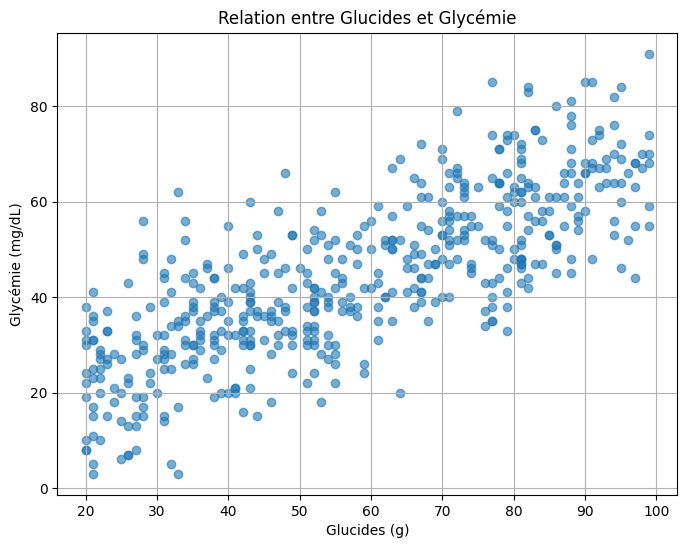

In [ ]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Courbe d'apprentissage (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Évolution de la perte")
plt.xlabel("Épochs")
plt.ylabel("Loss")
plt.show()


plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

# Exemple de repas (tu peux modifier les valeurs) :
new_meal = np.array([[40, 20, 10, 5, 65, 340]])  # [glucides, proteines, lipides, fibres, IG, calories]

# Normalisation avec le même scaler que l’entraînement
new_meal_scaled = scaler.transform(new_meal)

# Prédiction
predicted_glycemia = model.predict(new_meal_scaled)

# Affichage du résultat
print(f"Taux de glycémie prédit : {predicted_glycemia[0][0]:.2f} mg/dL")

repas_batch = np.array([
    [50, 15, 8, 4, 70, 360],
    [25, 20, 12, 6, 45, 310]
])

repas_batch_scaled = scaler.transform(repas_batch)
preds = model.predict(repas_batch_scaled)

for i, pred in enumerate(preds):
    print(f"Repas {i+1} → Glycémie prédite : {pred[0]:.2f} mg/dL")

# Prédiction sur l'ensemble de test
y_pred = model.predict(X_test)

# Création d’un DataFrame de comparaison
comparison = pd.DataFrame({
    'Glycémie réelle (mg/dL)': y_test.values[:5],
    'Glycémie prédite (mg/dL)': y_pred[:5].flatten()
})

# Affichage
print("Comparaison sur 5 exemples :")
print(comparison)

plt.figure(figsize=(8, 6))
plt.scatter(df['glucides'], df['glycemie'], alpha=0.6)
plt.title("Relation entre Glucides et Glycémie")
plt.xlabel("Glucides (g)")
plt.ylabel("Glycémie (mg/dL)")
plt.grid(True)
plt.show()




Ce bloc génère des visualisations (histogrammes, heatmaps, etc.) pour explorer la distribution des variables et les corrélations entre elles.